# **Short NumPy and scikit-image Tutorial**

### Course: Computer Vision


---



This is a very short introduction to [numpy](http://www.numpy.org) and [Scikit-image library](http://scikit-image.org/), including the main operations for image manipulation.

Numpy is the most important scientific package in the Python ecosystem, because it provides a common datastructure on which many other packages are build on.

What is an image? Images are n-dimensional arrays (`ndarray`) where each element corresponds to a pixel.

The most common image kinds are:

1. **Binary images**, containing 1 channel of X rows and Y columns. They use logical (True/False, 0/1...) values.

2. **Grey-level images**, containing 1 channel of X rows and Y columns. They use a set of values, depending on the data type (float, uint8, uint16...)

3. **RGB /color images**, containing 3 channels per color (RGB). Sometimes, **RGBA (4 channels)** images are used.

Images manipulated by the Scikit-image library are stored as **Numpy arrays**.

 See [A crash course on NumPy for images](http://scikit-image.org/docs/dev/user_guide/numpy_images.html#numpy-indexing) for more information.

 Other libraries we will use:

* [**Matplotlib**](https://matplotlib.org/) Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python.

* [**Scikit-learn**](https://scikit-learn.org/stable/) Simple and efficient tools for predictive data analysis.

* [**Scipy**](https://scipy.org/) SciPy provides algorithms for optimization, integration, interpolation, eigenvalue problems, algebraic equations, differential equations, statistics and many other classes of problems.

* [**OpenCV**](https://opencv.org/) OpenCV library is an open source computer vision and machine learning software library.

* [**Pillow**](https://python-pillow.org/) Pillow (PIL) is an acronym for Python Imaging Library.




![Python scientific ecosystem](http://luispedro.org/files/talks/2013/EuBIAS/figures/sciwheel.png)

# **Some fundamental concepts**
Before exploring the downloaded images, let's first understand some fundamental concepts using basic matrix operations.

### **What is an image?**
Basically, an image is a matrix

\begin{pmatrix}
1 & 0 & 1 & 0 & 1 & 0 & 1 & 0 \\
0 & 1 & 0 & 1 & 0 & 1 & 0 & 1 \\
1 & 0 & 1 & 0 & 1 & 0 & 1 & 0 \\
0 & 1 & 0 & 1 & 0 & 1 & 0 & 1 \\
1 & 0 & 1 & 0 & 1 & 0 & 1 & 0 \\
0 & 1 & 0 & 1 & 0 & 1 & 0 & 1 \\
1 & 0 & 1 & 0 & 1 & 0 & 1 & 0 \\
0 & 1 & 0 & 1 & 0 & 1 & 0 & 1 \\
\end{pmatrix}

How is shown this matrix as an image:

In [124]:
# Let's download some libraries first
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

### **Loading and visualizing an image from disk**

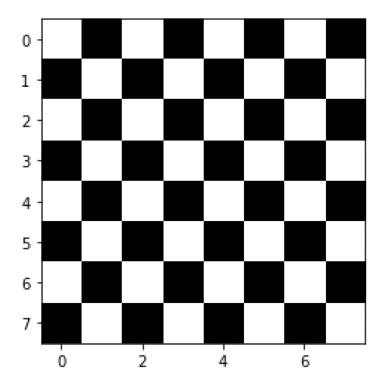

In [125]:
img = mpimg.imread("images_notebook/Checkerboard.png")
plt.imshow(img)
plt.axis("off")
plt.show()

### **How to create an image?**
Next, we will explore some basic ways to create images and inspect their properties.

In [126]:
import numpy as np

In [127]:
checkerboard = np.array([[1, 0, 1, 0, 1, 0, 1, 0],
                         [0, 1, 0, 1, 0, 1, 0, 1],
                         [1, 0, 1, 0, 1, 0, 1, 0],
                         [0, 1, 0, 1, 0, 1, 0, 1],
                         [1, 0, 1, 0, 1, 0, 1, 0],
                         [0, 1, 0, 1, 0, 1, 0, 1],
                         [1, 0, 1, 0, 1, 0, 1, 0],
                         [0, 1, 0, 1, 0, 1, 0, 1]])

In [128]:
print(checkerboard)

[[1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]
 [1 0 1 0 1 0 1 0]
 [0 1 0 1 0 1 0 1]]


### **How to visualize an image?**
There are several libraries available for image visualization. In this notebook, we will use Matplotlib.

By default, imshow() interprets a 2D matrix as a scalar image and maps its values to colors using the **viridis** colormap.

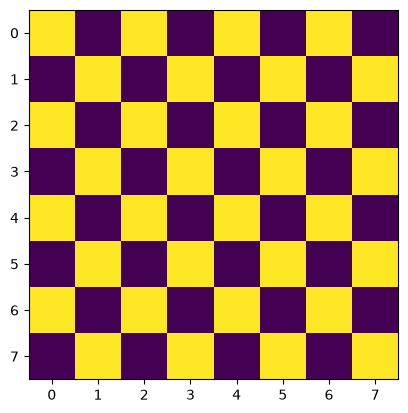

In [129]:
plt.imshow(checkerboard)
# plt.axis("off") # try uncomment this line
plt.show()

Using **cmap='gray'** displays the matrix as a grayscale image, where lower values appear darker and higher values appear brighter.

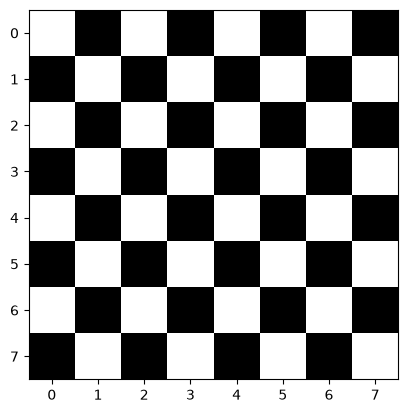

In [130]:
plt.imshow(checkerboard, cmap='gray')
plt.show()

***Question:*** Is the above image a Binary or a Grayscale image?

### **Inspecting the Image Properties**

- `checkerboard.dtype` shows the data type used to store the pixel values (e.g., `int64`, `uint8`, `float64`).
- `checkerboard.ndim` returns the number of dimensions of the array. A grayscale image is typically a 2D array.
- `checkerboard.shape` gives the size of the array along each dimension, in the form `(rows, columns)`.
- `checkerboard.size` returns the total number of elements (pixels) in the array.
- `checkerboard.min()` returns the minimum pixel value in the image.
- `checkerboard.max()` returns the maximum pixel value in the image.

In [131]:
print(checkerboard.dtype)
print(checkerboard.ndim)
print(checkerboard.shape)
print(checkerboard.size)
print(checkerboard.min())
print(checkerboard.max())

int64
2
(8, 8)
64
0
1


**Exercise:** Check the [NumPy documentation](https://www.numpy.org) to find other ways to create an array.

Create a three-dimensional array of **100 × 100 × 3** elements, with integer values stored using **32 bits**. How many different ways can you find to create this array?

**Help:** [Array creation](https://docs.scipy.org/doc/numpy-1.13.0/user/basics.creation.html)

In [132]:
new_array = np.zeros((100,100,3), dtype=np.uint32)
print(new_array.ndim)
print(new_array.shape)
print(new_array.max())
print(new_array.min())

3
(100, 100, 3)
0
0


### **Creating a 2D array (image) with zeros**

We can create a simple grayscale image using `np.zeros()`. This creates a **5 × 8** array where all pixel values are initially set to `0`.


In [133]:
image=np.zeros((5,8))
print(image)

[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]


We can use NumPy to inspect individual pixels and several properties of the image:

- `image[0, 1]` returns the value of the pixel at **row 0, column 1**.

In [134]:
print(image[0,1]) #check the pixel (0,1) value
print(image.dtype)
print(image.ndim)
print(image.shape)
print(image.size)
print(image.min())
print(image.max())

0.0
float64
2
(5, 8)
40
0.0
0.0


### **Building a 2D array (image) with random values**
Visualizing its values and some properties. Note that **np.random.rand(5, 5)** generates values between 0 and 1.

In [135]:
image2 = np.random.rand(5,5)
print(image2)

[[0.41817507 0.13272292 0.61500364 0.13257424 0.34147154]
 [0.92075502 0.08903335 0.06759159 0.73644018 0.93288687]
 [0.82032246 0.10145259 0.27257116 0.43824677 0.23663297]
 [0.86257103 0.94429677 0.7168033  0.4312008  0.1789191 ]
 [0.52207474 0.61273009 0.93917511 0.41494023 0.81547451]]


In [136]:
print(image2.dtype)
print(image2.shape)

float64
(5, 5)


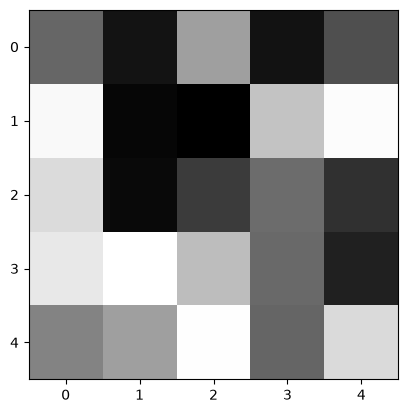

In [137]:
plt.imshow(image2, cmap='gray')
plt.show()

In [138]:
print(image2.min())
print(image2.max())

0.06759158928626574
0.944296770977818


In [139]:
print(image2.mean())
print(image2.mean(0)) # mean by rows
print(image2.mean(1)) # mean by columns

0.5077626417935674
[0.70877966 0.37604714 0.52222896 0.43068044 0.501077  ]
[0.32798948 0.5493414  0.37384519 0.6267582  0.66087894]


In [140]:
print(image2.sum())

12.694066044839186


### **Basic image manipulation**

NumPy arrays representing images can be of different numerical types, such as integer or float.

See [Image data types and what they mean](http://scikit-image.org/docs/dev/user_guide/data_types.html#data-types) for more information about these types and how scikit-image treats them.

How shall we change the type of an image?

Create an image of type **uint8** specifying its pixel values.

In [141]:
ii=np.array([[0, 255, 0],
             [255,0,255],
             [0, 255, 0]],
             dtype=np.uint8)
print(ii)

[[  0 255   0]
 [255   0 255]
 [  0 255   0]]


**Note:** `np.uint8` stores only whole numbers in the range 0–255. Any decimal values are truncated when converted to `uint8`.

In [142]:
ii=np.array([[0, 25.5, 0],
             [2.55,0,255],
             [0, 255, 0]],
             dtype=np.uint8)
print(ii)

[[  0  25   0]
 [  2   0 255]
 [  0 255   0]]


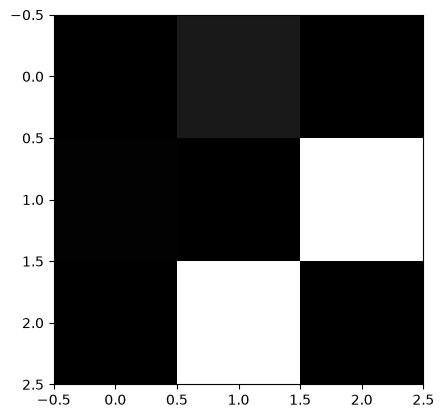

In [143]:
import matplotlib.pyplot as plt

plt.imshow(ii, cmap='gray')
plt.show()

In [144]:
print(ii.dtype)
print(ii.shape)

uint8
(3, 3)



Convert the previous image from **uint8** to **float**

In [145]:
ii2 = ii.astype(float)
print(ii2)

[[  0.  25.   0.]
 [  2.   0. 255.]
 [  0. 255.   0.]]


In [146]:
from skimage import img_as_float

ii_float = img_as_float(ii)
print(ii_float)

[[0.         0.09803922 0.        ]
 [0.00784314 0.         1.        ]
 [0.         1.         0.        ]]


**What is going on?!**

What is the difference between the two operations? Before checking the answer below, try to understand what is happening. Also, do some research to understand the differences between the two methods: `astype(float)` and `img_as_float()`.

In [147]:
print(ii.dtype)
print(ii2.dtype)
print(ii_float.dtype)

uint8
float64
float64


**Answer:** `astype(float)` only converts the data type, preserving the original values. `img_as_float()` converts the image to floating point and scales integer pixel values to the range [0, 1].

**Question:** Can we convert an image from `uint8` to `float`? And from `float` to `uint8`?

Arithmetic operations on the array: we should take into account that the type has to be respected.

In [148]:
# Create a 3×3 uint8 NumPy array and print its values and data type.
iarr = np.array([[1,2,3],
                 [3,1,2],
                 [2,3,1]],
                 dtype='uint8')
print(iarr)
print(iarr.dtype)

[[1 2 3]
 [3 1 2]
 [2 3 1]]
uint8


In [149]:
# Copy the array and print its values and data type.
iarr_2 = iarr.copy()
print(iarr_2)
print(iarr_2.dtype)

[[1 2 3]
 [3 1 2]
 [2 3 1]]
uint8


In [150]:
# Multiply the array values by 2 and print the result and data type.
print(iarr_2*2)
print(iarr_2.dtype)

[[2 4 6]
 [6 2 4]
 [4 6 2]]
uint8


**Uncomment and run the following cell** (line by line). You will see that uncommenting the first line will generate an error because iarr_2 has type uint8, and multiplying it in place by 2.5 produces float64 values that cannot be automatically stored back into a uint8 array.

In [151]:
#iarr_2*=2.5 # will generate an error

print(iarr_2*2.5) # this works as it creates a new array


[[2.5 5.  7.5]
 [7.5 2.5 5. ]
 [5.  7.5 2.5]]


The solution is to convert the array elements to float.

Check in [numpy](https://docs.scipy.org/doc/numpy-1.13.0/user/basics.types.html) the different types and how to convert an array to a different type.

In [152]:
# Convert the array to float, multiply its values by 2.5, and print the result.
iarr_float = iarr_2.astype(float)*2.5
print(iarr_float)

[[2.5 5.  7.5]
 [7.5 2.5 5. ]
 [5.  7.5 2.5]]


### **Reduction/aggregation operations**

In [153]:
print(iarr.min())
print(iarr.max())

1
3


In [154]:
print(iarr.mean())

2.0


### **Boolean operations**

In [155]:
# Create a Boolean array indicating which values are greater than the mean.
is_greater = (iarr > iarr.mean())
print(is_greater)
print(is_greater.dtype)

[[False False  True]
 [ True False False]
 [False  True False]]
bool


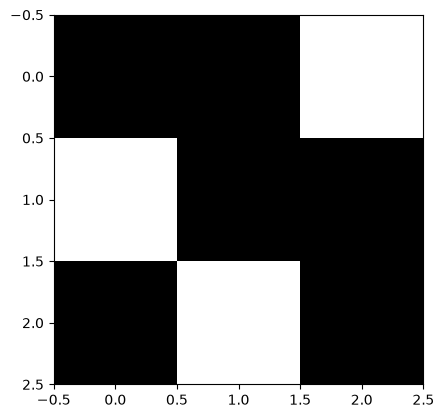

In [156]:
# Display the Boolean array as a grayscale image.
plt.imshow(is_greater, cmap='gray')
plt.show()

[[ True False False]
 [False  True False]
 [False False  True]]
bool


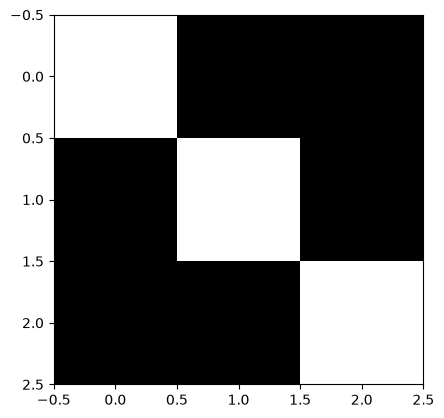

In [157]:
# Identify values below the mean, print the Boolean array and its data type,
# and display it as a grayscale image.
is_smaller = iarr<iarr.mean()
print(is_smaller)
print(is_smaller.dtype)
plt.imshow(is_smaller, cmap='gray')
plt.show()

In [158]:
# # Keep only the values greater than the mean by
# multiplying the array by the Boolean mask.
print(iarr*is_greater)

[[0 0 3]
 [3 0 0]
 [0 3 0]]


In [159]:
# Keep only the values smaller than the mean by applying the Boolean mask.
print(iarr*is_smaller)

[[1 0 0]
 [0 1 0]
 [0 0 1]]


### **Creating a color image (3D array)**

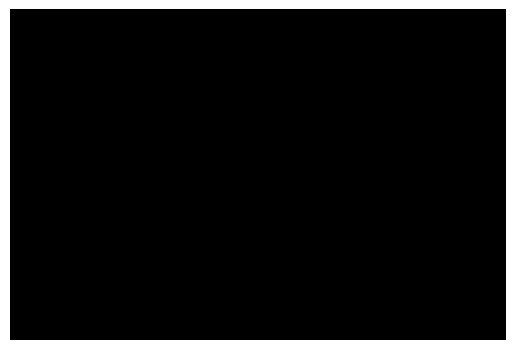

In [160]:
# Create a 20×30 black RGB image and display it without axes.
ii=np.zeros((20,30,3), # 3 channels (RGB)
            dtype=np.uint8)

plt.imshow(ii)
plt.axis('off')
plt.show()

### **Creating Arrays with** `np.arange()`
`np.arange()` creates a NumPy array of evenly spaced values within a specified range: `np.arange(start, stop, step)`

In [161]:
# Create a vector from 0 to 90 with steps of 10.
ex = np.arange(0, 100, 10, dtype=np.uint8)
print(ex)

[ 0 10 20 30 40 50 60 70 80 90]


In [162]:
# create a sequence from 0 to 28 in steps of 1.
np.arange(29)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28])

In [163]:
# create a sequence from 5 to 9 with a step of 2.
np.arange(5,10,2)

array([5, 7, 9])

### **Assigning RGB Values to Image Rows**
We are going to modify the pixels within the original black image. `np.arange(29) is used to create 29 increasing values (0–28) that can be assigned across the 29 columns of the image.


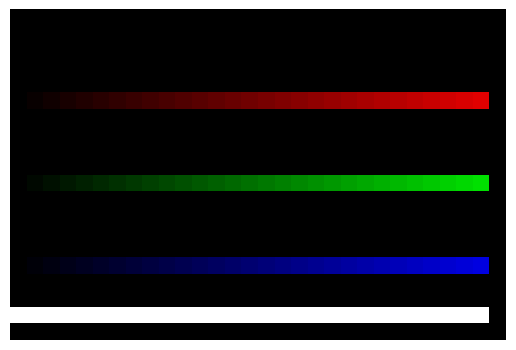

In [164]:
# Add red, green, and blue values to different rows, draw a white row, and display the RGB image.
ii[ 5, 0:29, 0] = 8*np.arange(29)  ## Row 5, columns between 0:29, Channel 0 (=Red)
ii[10, 0:29, 1] = 8*np.arange(29)  ## Row 10, columns between 0:29, Channel 1 (=Green)
ii[15, 0:29, 2] = 8*np.arange(29)  ## Row 15, columns between 0:29, Channel 2 (=Blue)

ii[18, 0:29, :] = [255,255,255]    ## Row 18, columns between 0:29, all channels

plt.imshow(ii)
plt.axis('off')
plt.show()

### **Reading and writing images**

Utilities to read and write images in various formats are available in the Module `io`.


`io.imread()` reads an image file and loads it into a NumPy array, where pixel values can be accessed and processed programmatically.

The dtype is:  uint8
The min is:  6
The max is:  246


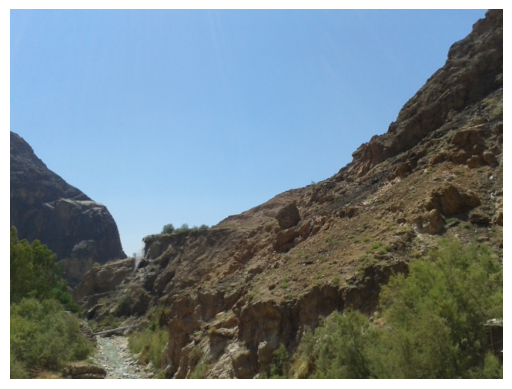

In [165]:
# Load an image, print its data type and pixel value range, and display the image.

from skimage import io #necessary to read and write images

img = io.imread('images_notebook/jordan.jpeg')

print('The dtype is: ', img.dtype)
print('The min is: ', img.min())
print('The max is: ', img.max())

plt.imshow(img) #Visualizing a figure with the image
plt.axis('off')
plt.show()


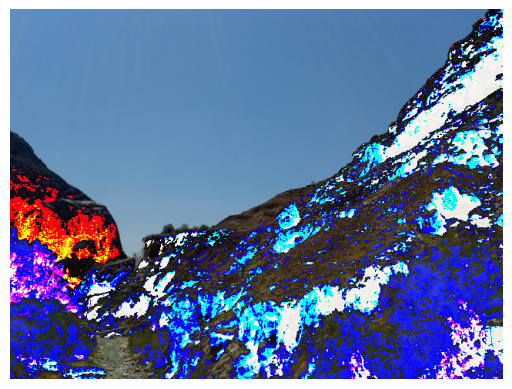

In [166]:
# # Decrease the image pixel values by 50 and display the resulting image.
# img2 = img.astype(int)-50 # we can solve the problem by simply assigning it to int type
img2 = img-50
plt.imshow(img2)
plt.axis('off')
plt.show()

In [167]:
# Print the modified image's data type and its minimum and maximum pixel values.
print(img2.dtype)
print(img2.min())
print(img2.max())

uint8
0
255


### **Saving Images with** `io.imsave()`

`io.imsave()` saves a NumPy array as an image file on disk.

**Note:** In Google Colab, saved files are stored in the current runtime environment and will be lost when the runtime is disconnected or reset unless they are downloaded or saved to Google Drive.



In [168]:
# Save the modified image to a BMP file using `io.imsave()`.
io.imsave('images_notebook/dark_image.bmp',img2)

### **Exercise: Visualize the image you just saved to disk**

- Before looking at the answer below (ploted below), take a moment to think about what happened.

- Can you explain the changes in the image? ***What happened to the colors***, and why do they appear different from the original image?

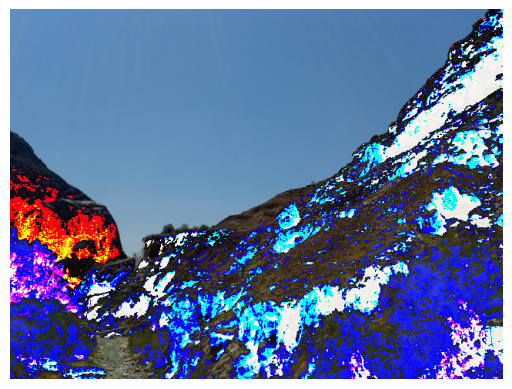

In [169]:
plt.imshow(img2)
plt.axis('off')
plt.show()

### **Why did the colors change?**

The colors changed because `img2 = img - 50` subtracts 50 from every RGB channel, making the image darker. However, since `uint8` can only store values from 0 to 255, values below 0 wrap around to the top of the range instead of becoming negative (e.g., `10 - 50 = -40 → 216`), causing some colors to become very saturated and distorted.

### **Subtracting Values After Converting to Float**

In the following example, `img.astype(float)` converts the image from `uint8` to floating-point values, allowing pixel values to become negative. Then, `- 50` subtracts 50 from every pixel value without the `uint8` wrap-around problem.

The code prints the new data type and the minimum and maximum pixel values, then displays the modified image.

Unlike the previous example, values below 0 (zero) remain negative instead of wrapping around, so the colors are not distorted by `uint8` overflow.

In this example, the image looks mostly white because imshow() clips float RGB values above 1 to 1. Since most values are much larger than 1, most pixels become white.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-44.0..196.0].


float64
-44.0
196.0


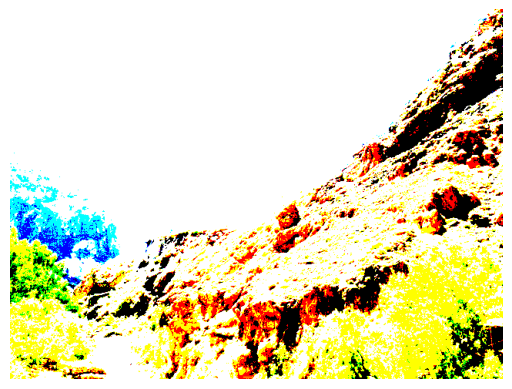

In [170]:
# Convert the image to float, subtract 50 from all pixel values, print the dtype and value range, and display the result.
img3 = img.astype(float) - 50

print(img3.dtype)
print(img3.min())
print(img3.max())

plt.imshow(img3)
plt.axis('off')
plt.show()

### **Removing Non-Positive Pixel Values**

Below we create a mask to remove non-positive values, convert the image to uint8, check its value range, and display it.

In summary, `img3 > 0` creates a mask:

- **True** → positive values are kept.
- **False** → zero or negative values become `0`.

Thus, `img3 *= mask` removes non-positive values (`≤ 0`).

In this case the image can be visualized correctly after converting to np.uint8, because the pixel values have already been made non-negative and remain within the 0–255 range.

uint8
0
196


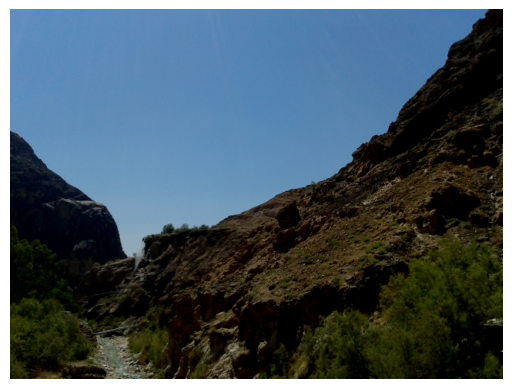

In [171]:
mask = img3>0
img3 *= mask
img3 = img3.astype(np.uint8)

print(img3.dtype)
print(img3.min())
print(img3.max())

plt.imshow(img3)
plt.axis('off')
plt.show()

### **Spatial and Photometric Resolution**

Scikit-image provides a collection of [standard test images](https://scikit-image.org/docs/stable/api/skimage.data.html) through the `data` module, including `astronaut`, `binary_blobs`, `camera`, `checkerboard`, `chelsea`, `clock`, `coffee`, and `coins`, among others.

Consider the following example:


In [172]:
# Load the built-in 'coins' sample image from Scikit-image into a NumPy array.
from skimage import data
coins = data.coins()

In [173]:
# Display the image data type.
print(coins.dtype)

# Display the image dimensions (height, width) to verify its shape.
print(coins.shape)  # Check the image dimensions and number of channels.

# Display the total number of pixels in the image.
print(coins.size)

print(coins.min())
print(coins.max())

uint8
(303, 384)
116352
1
252


To visualize the effect of resizing, we display the image at its original resolution, since Matplotlib typically rescales images for improved visualization.

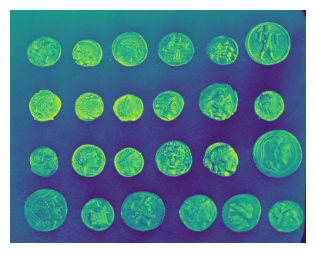

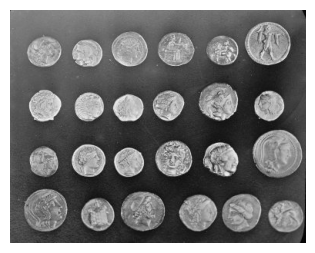

In [174]:
# To display the image at approximately its original pixel dimensions, dpi = 100 sets the display resolution,
# while figsize=(width/dpi, height/dpi) adjusts the figure size accordingly.
dpi = 100
plt.figure(figsize=(coins.shape[1] / dpi, coins.shape[0] / dpi), dpi=dpi)

plt.imshow(coins)
plt.axis('off')
plt.show()

plt.figure(figsize=(coins.shape[1] / dpi, coins.shape[0] / dpi), dpi=dpi)

plt.imshow(coins, cmap='gray') # we can visualize the image 'camera' in gray scale colormap,
                                #you can look at matplotlib for different colormaps
plt.axis('off')
plt.show()

### **Rescale and Resize Functions**

Sometimes, we need to change the spatial or photometric resolution of an image. For this purpose, we can use functions such as `rescale` and `resize`.

- **`rescale()`** changes the image size using a **scale factor**.
- **`resize()`** changes the image to a **specific target shape**.

> **Note:** `rescale()` and `resize()` may change the image data type and value range. Because these functions use interpolation, new pixel values can also be introduced. Therefore, it is important to check the output `dtype`, minimum, and maximum values after resizing or rescaling.


float64
(152, 192)
0.018911084727072956
0.9155880858770281


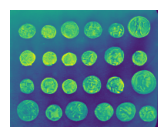

In [175]:
from skimage.transform import rescale

rescaled = rescale(coins, 0.5)

print(rescaled.dtype)
print(rescaled.shape) # check number of channels
print(rescaled.min())
print(rescaled.max())

# To display the image at approximately its original pixel dimensions, dpi = 100 sets the display resolution,
# while figsize=(width/dpi, height/dpi) adjusts the figure size accordingly.
dpi = 100
plt.figure(figsize=(rescaled.shape[1] / dpi, rescaled.shape[0] / dpi), dpi=dpi)

plt.imshow(rescaled)
plt.axis('off')
plt.show()

> **Note:** When using `resize()`, changing the width and height independently can distort the image. If the aspect ratio is not preserved, objects in the image may appear stretched or compressed (also illustrated below).

float64
(512, 512)
0.010465016084558822
0.9478941674325981


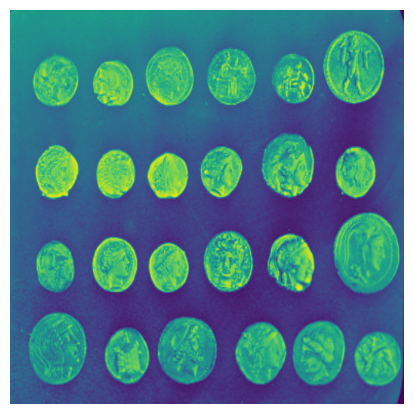

In [176]:

from skimage.transform import resize

# Resize: change the image to exactly 256 × 256 pixels
fixed = resize(coins, (512, 512))
print(fixed.dtype)
print(fixed.shape) # check number of channels
print(fixed.min())
print(fixed.max())

dpi = 100
plt.figure(figsize=(fixed.shape[1] / dpi, fixed.shape[0] / dpi), dpi=dpi)

plt.imshow(fixed)
plt.axis('off')
plt.show()

### **How to preserve the grayscale range?**

**preserve_range=True** tells rescale() to don't normalize the pixel intensities; keep their original grayscale range.

Why can this be important? By default, **skimage.transform.rescale()** may convert the image to floating point and normalize the intensity range. For example, an image with values from 0 to 255 could become values from 0 to 1. This way, the spatial dimensions change, but the grayscale intensity range is preserved.

In [177]:
# Display the original image's data type, minimum and maximum pixel values, and dimensions.
print(coins.dtype, np.round(coins.min(), 4), np.round(coins.max(), 4), coins.shape)

# Rescale the image to 50% of its original spatial dimensions.
# By default, the image values are converted to a floating-point range.
rescaled2a = rescale(coins, 0.5)

# Display the rescaled image's data type, value range, and dimensions.
print(rescaled2a.dtype, np.round(rescaled2a.min(), 4), np.round(rescaled2a.max(), 4), rescaled2a.shape)

# Rescale the image to 50% while preserving the original pixel value range.
rescaled2b = rescale(coins, 0.5, preserve_range=True)

# Display the rescaled image's data type, value range, and dimensions.
print(rescaled2b.dtype, np.round(rescaled2b.min(), 4), np.round(rescaled2b.max(), 4), rescaled2b.shape)

uint8 1 252 (303, 384)
float64 0.0189 0.9156 (152, 192)
float64 4.8223 233.475 (152, 192)


### **Resize function with** `img_as_ubyte` or `preserve_range=True`
`img_as_ubyte()` converts an image to 8-bit unsigned integer format (uint8), typically mapping pixel values to the range 0–255.

> **Note:** Below, we don't display the image at its original resolution. Since the image is only **48 × 48 pixels**, the individual pixels become visible, creating a noticeable **pixelation effect**.

uint8 199 25 (48, 48)


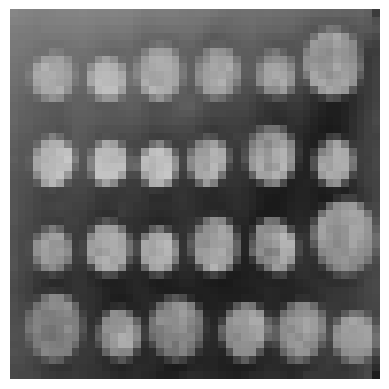

In [178]:
from skimage.transform import resize
from skimage import img_as_ubyte # img_as_ubyte Convert an image to 8-bit unsigned integer format

resized = img_as_ubyte(resize(coins,(48,48)))
print(resized.dtype,resized.max(), resized.min(), resized.shape)

plt.imshow(resized, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

float64 198.5012890372631 25.26806810670181 (48, 48)


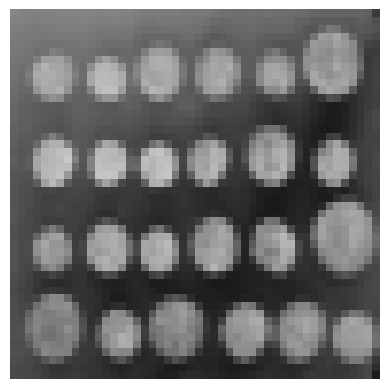

In [179]:
from skimage.transform import resize
from skimage import img_as_ubyte # img_as_ubyte Convert an image to 8-bit unsigned integer format

resized = resize(coins,(48,48), preserve_range=True)
print(resized.dtype, resized.max(), resized.min(), resized.shape)

plt.imshow(resized, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

> **Questions:** What is the difference between rescale and resize?
> **Think about cases where you would use `rescale()` or `resize()`.** Check [the next example](https://scikit-image.org/docs/stable/auto_examples/transform/plot_rescale.html). More examples can be seen in the [Matplotlib Image tutorial](https://matplotlib.org/users/image_tutorial.html).

### **How to rescale intensity values?**

uint8 0 255 (512, 512)


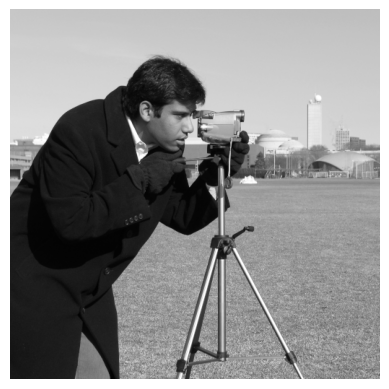

In [180]:
# Load the built-in camera test image from Scikit-image.
camera = data.camera()

# Display the image data type, pixel-value range, and dimensions.
print(camera.dtype, camera.min(), camera.max(), camera.shape)

# Display the image using a grayscale colormap.
plt.imshow(camera, cmap='gray')

# Hide the axes for a cleaner visualization.
plt.axis('off')

# Display the image.
plt.show()

In [181]:
# Divide all pixel values by 2 to reduce the image intensity range by half.
camera2 = camera / 2

# Display the data type, minimum and maximum pixel values, and image dimensions.
print(camera2.dtype, camera2.min(), camera2.max(), camera2.shape)

float64 0.0 127.5 (512, 512)


> **Note:** Subplots are explained in more detail later.

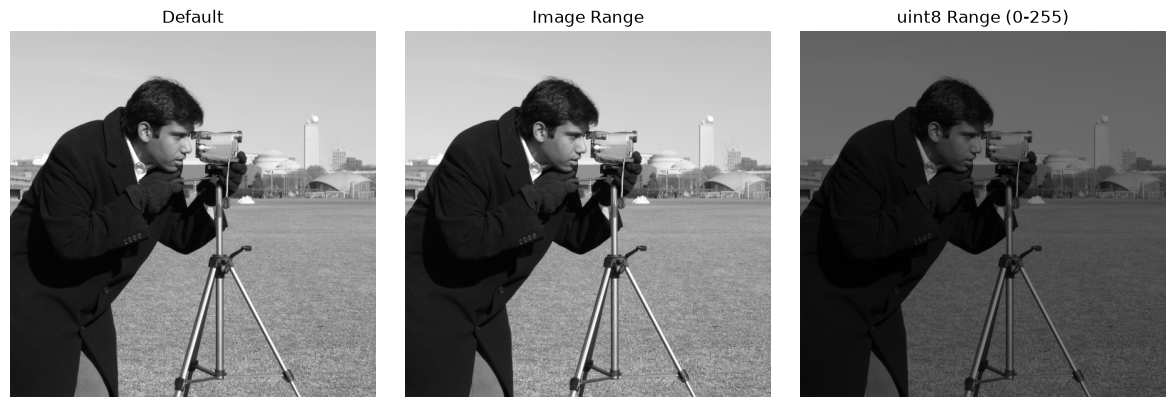

In [182]:
# Create a figure with 1 row and 3 columns to display three images side by side.
fig = plt.figure(figsize=(12, 4))

# Create the first subplot.
fig.add_subplot(1, 3, 1)

# Display using Matplotlib's default value range.
plt.imshow(camera2, cmap='gray')
plt.title('Default')
plt.axis('off')

# Create the second subplot.
fig.add_subplot(1, 3, 2)

# Display using the image's actual minimum and maximum values.
# Similar to Matplotlib's default values.
plt.imshow(camera2, cmap='gray',
           vmin=camera2.min(), vmax=camera2.max())
plt.title('Image Range')
plt.axis('off')

# Create the third subplot.
fig.add_subplot(1, 3, 3)

# Display using the full uint8 range (0–255).
# This changes only the visualization, not the underlying image data.
plt.imshow(camera2, cmap='gray', vmin=0, vmax=255)
plt.title('uint8 Range (0-255)')
plt.axis('off')

# Adjust spacing between the subplots.
plt.tight_layout()

# Display the figure.
plt.show()

### **Summary**

`imshow()` maps pixel values to grayscale intensity using a display range:

- **Default:** Matplotlib automatically uses the image's minimum and maximum values.
- **`vmin`/`vmax` set to image min/max:** Explicitly uses the image's actual value range, giving a similar result to the default.
- **`vmin=0, vmax=255`:** Uses the full `uint8` range, which may change the image's contrast if its values do not span 0–255.

> **Key idea:** `vmin` and `vmax` control how pixel values are mapped to brightness when displaying an image.

float64 100.0 227.5 (512, 512)


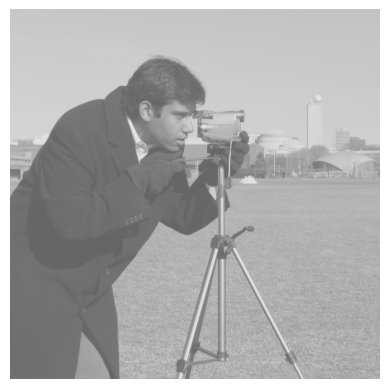

In [184]:
# Increase all pixel values by 100, making the image brighter.
camera3 = camera2 + 100

# Display the minimum and maximum pixel values and the image dimensions.
print(camera3.dtype, camera3.min(), camera3.max(), camera3.shape)

# Display the image using the uint8 intensity range (0–255).
plt.imshow(camera3, cmap='gray', vmin=0, vmax=255)

# Hide the axes for a cleaner visualization.
plt.axis('off')

# Display the image.
plt.show()

## **Displaying  images and graphics**

[Matplotlib](https://matplotlib.org/index.html) is a Python 2D plotting library which produces publication quality figures in a variety of hardcopy formats and interactive environments across platforms.

### **How to change the figure size?**
> **Note:** The following code only changes the visualization/display size; the underlying data remains unchanged.


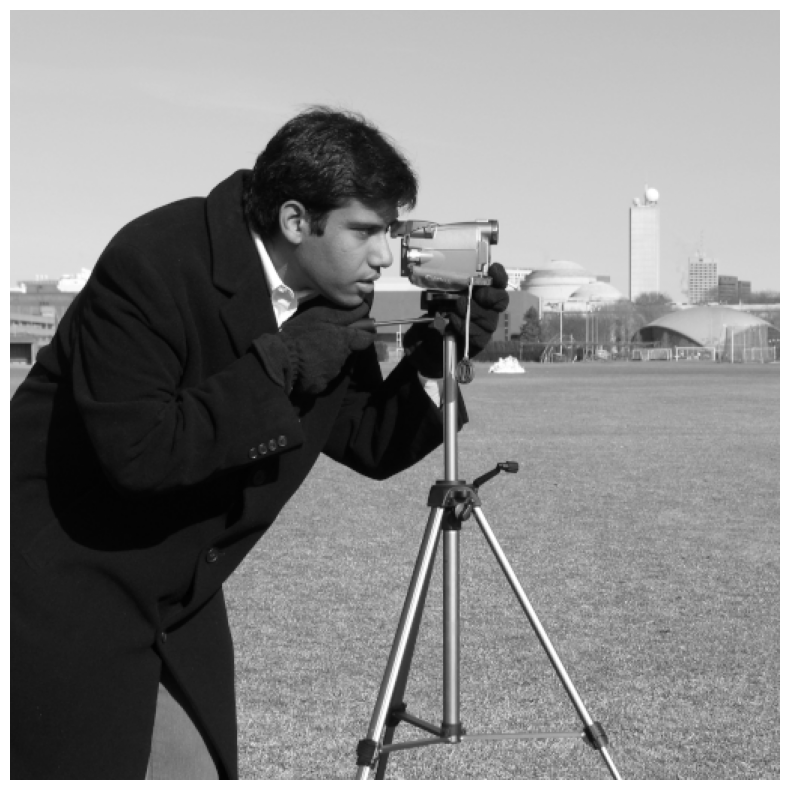

In [60]:
# Changes the figure size for visualization
fig = plt.figure(figsize=(10,10))

plt.imshow(camera, cmap='gray')
plt.axis('off')
plt.show()


### **How to visualize multiple images?**

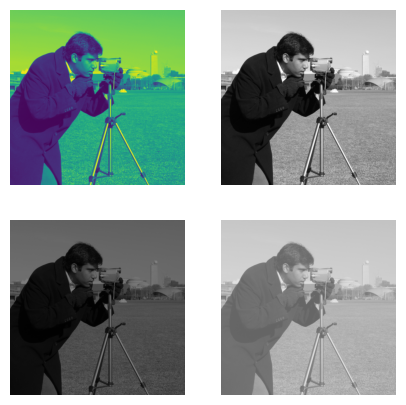

In [61]:
# Create a figure with a size of 5 × 5 inches.
fig = plt.figure(figsize=(5, 5))

# Create the first subplot in a 2 × 2 grid (position 1).
fig.add_subplot(2, 2, 1)

plt.imshow(camera)
plt.axis('off')

# Create the second subplot in the 2 × 2 grid (position 2).
fig.add_subplot(2, 2, 2)

plt.imshow(camera2, cmap='gray')
plt.axis('off')

# Create the third subplot in the 2 × 2 grid (position 3).
fig.add_subplot(2, 2, 3)

# Display camera2 using the full uint8 range (0–255).
# This changes only the visualization, not the underlying image data.
plt.imshow(camera2, vmin=0, vmax=255, cmap='gray')
plt.axis('off')

# Create the fourth subplot in the 2 × 2 grid (position 4).
fig.add_subplot(2, 2, 4)

# Display camera3 using the full uint8 range (0–255).
# This changes only the visualization, not the underlying image data.
plt.imshow(camera3, vmin=0, vmax=255, cmap='gray')
plt.axis('off')

# Display the complete figure with all four subplots.
plt.show()

### **Image conversion: from RGB to Grayscale**

Often, we need to convert color images to grayscale images.

An RGB image can be converted to a grayscale image using the `rgb2gray()` function.


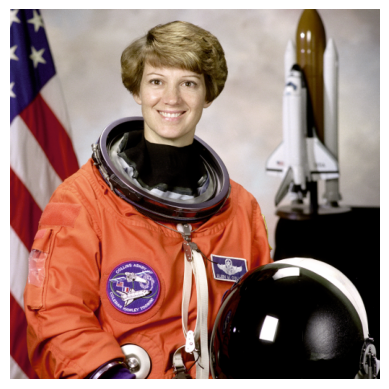

Note that dtype:  uint8 pixel.min:  0 pixel.max:  255 shape (512, 512, 3)


In [187]:
# Import the rgb2gray function for converting RGB images to grayscale.
from skimage.color import rgb2gray

# Load the built-in astronaut RGB image from scikit-image.
img = data.astronaut()

# Display the RGB image using Matplotlib.
plt.imshow(img)

# Hide the axes for a cleaner visualization.
plt.axis('off')

# Display the image.
plt.show()

# Print information about the image data:
print("Note that dtype: ", img.dtype,
      "pixel.min: ", img.min(),
      "pixel.max: ", img.max(),
      "shape", img.shape)

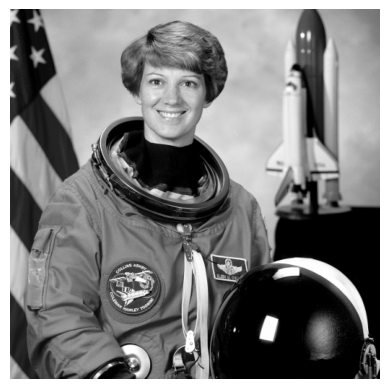

dtype:  float64 gray.max:  0.0 pixel.max:  1.0 shape:  (512, 512)


In [188]:
# Convert the RGB image to a grayscale image.
# The resulting pixel values are floating-point numbers typically in the range 0–1.
img_gray = rgb2gray(img)

# Display the grayscale image using a grayscale colormap.
plt.imshow(img_gray, cmap='gray')

# Hide the axes for a cleaner visualization.
plt.axis('off')

# Display the image.
plt.show()

# Print information about the grayscale image:
print("dtype: ", img_gray.dtype,
      "gray.max: ", img_gray.min(),
      "pixel.max: ", img_gray.max(),
      "shape: ", img_gray.shape)

> ***Question:*** Given a gray image, how would it be looking if it is converted to RGB values (i.e. 3D array)?

## Conversion from RGBA to RGB

Often you can find color images in format [RGBA](https://en.wikipedia.org/wiki/Alpha_compositing#Alpha_blending), 4D arrays. **RGBA** has 24 bits for **RGB** color, with an additional 8-bit value for transparency.

The forth component shows the coefficient of blending of each channel. Converting an **RGBA** image to an **RGB** image by alpha blending it with a background is performend by the command `rgba2rgb()`.

dtype:  uint8
shape:  (500, 500, 4)
min/max values:  0 255


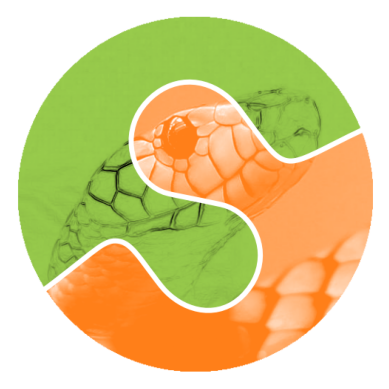

In [64]:
# Load the built-in logo image from scikit-image.
img_rgba = data.logo()

# Print the image data type (dtype).
print("dtype: ", img_rgba.dtype)
print('shape: ', img_rgba.shape) ## check the number of channels
print('min/max values: ', img_rgba.min(), img_rgba.max())

plt.imshow(img_rgba)
plt.axis('off')
plt.show()

dtype:  float64
shape:  (500, 500, 3)
min/max values:  0.0 1.0


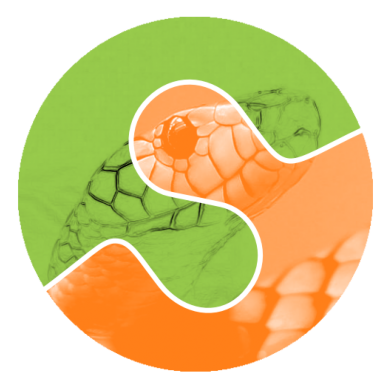

In [65]:
# Import the rgba2rgb function to convert an RGBA image to an RGB image.
from skimage.color import rgba2rgb

# Convert the RGBA image to an RGB image.
# The alpha (transparency) channel is removed and its effect is incorporated
# into the RGB values. This changes the image representation, not just its visualization.
img_rgb = rgba2rgb(img_rgba)

print("dtype: ", img_rgb.dtype)
print('shape: ', img_rgb.shape) ## check the number of channels
print('min/max values: ', img_rgb.min(), img_rgb.max())

plt.imshow(img_rgb)
plt.axis('off')
plt.show()


**Image transformations and visualization**

In the following example, we work with the built-in Chelsea cat image from `scikit-image` and demonstrate several basic image transformations and visualization techniques. We first display the original RGB image, then convert it to grayscale. We modify the grayscale image by multiplying and dividing its pixel values to create brighter and darker versions. The example also uses `min()`, `max()`, and `dtype` to examine the image's pixel values and data type, showing how these properties affect image processing and visualization.

> **Note:** Here, we use `axs` to access and control each subplot individually. This is an alternative to creating subplots one at a time with `fig.add_subplot()`, and is especially convenient when working with multiple subplots.


float64 0.03024156862745098 1.5112219607843138
float64 0.007560392156862745 0.37780549019607845


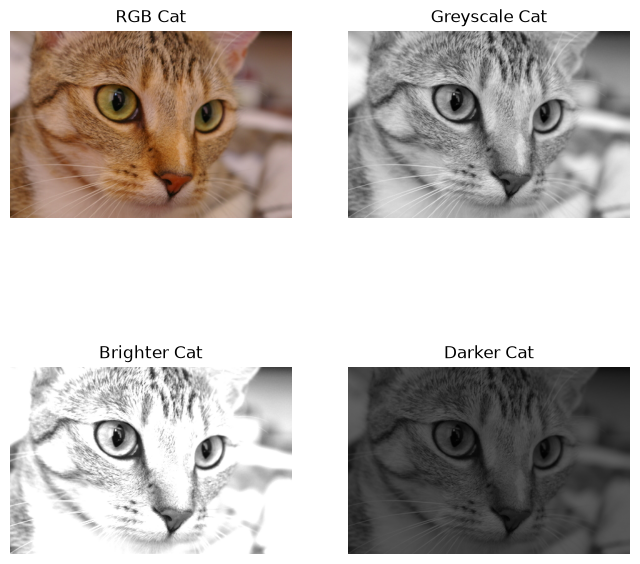

In [189]:

# Load the built-in Chelsea cat image from scikit-image.
cat = data.chelsea()

# Create a figure containing 2 rows and 2 columns of subplots.
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))


# ---------------------------------------------------------
# 1. Display the original RGB image
# ---------------------------------------------------------

# Select the first subplot (row 1, column 1).
ax = axs[0, 0]

# Display the original RGB cat image.
ax.imshow(cat)

# Hide the x- and y-axis.
ax.axis('off')

# Add a title to the subplot.
ax.set_title('RGB Cat')


# ---------------------------------------------------------
# 2. Convert and display the grayscale image
# ---------------------------------------------------------

# Select the second subplot (row 1, column 2).
ax = axs[0, 1]

# Convert the RGB image to grayscale and display it.
# rgb2gray() converts the image to floating-point values
# between 0 and 1.
ax.imshow(rgb2gray(cat), cmap='gray')

# Hide the x- and y-axis.
ax.axis('off')

# Add a title to the subplot.
ax.set_title('Greyscale Cat')


# ---------------------------------------------------------
# 3. Make the grayscale image brighter
# ---------------------------------------------------------

# Select the third subplot (row 2, column 1).
ax = axs[1, 0]

# Convert the RGB image to grayscale.
cat_gray = rgb2gray(cat)

# Multiply the grayscale pixel values by 2.
# This increases the brightness of the image.
cat_brighter = cat_gray * 2

# Print information about the resulting image:
print(cat_brighter.dtype, cat_brighter.min(), cat_brighter.max())

# Display the brighter grayscale image.
# cmap='gray' displays the image using a grayscale colour map.
# vmin=0 and vmax=1 define the range used for displaying the image.
# Values above 1 will therefore appear as white (saturated pixels).
ax.imshow(cat_brighter, cmap='gray', vmin=0, vmax=1)

# Hide the x- and y-axis.
ax.axis('off')

# Add a title to the subplot.
ax.set_title('Brighter Cat')


# ---------------------------------------------------------
# 4. Make the grayscale image darker
# ---------------------------------------------------------

# Divide the grayscale pixel values by 2.
# This decreases the brightness of the image.
cat_darker = cat_gray / 2

# Print information about the resulting image:
print(cat_darker.dtype, cat_darker.min(), cat_darker.max())

# Select the fourth subplot (row 2, column 2).
ax = axs[1, 1]

# Display the darker grayscale image.
ax.imshow(cat_darker, cmap='gray', vmin=0, vmax=1)

# Hide the x- and y-axis.
ax.axis('off')

# Add a title to the subplot.
ax.set_title('Darker Cat')


# Display the complete 2x2 figure.
plt.show()

In [ ]:
# ============================================================
# CHEAT SHEET — NumPy, Matplotlib & Scikit-image Tutorial
# ============================================================

# ── IMPORTS ─────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from skimage import io, data, img_as_float, img_as_ubyte
from skimage.color import rgb2gray
from skimage.transform import rescale, resize
from skimage.exposure import rescale_intensity


# ── 1. LOADING IMAGES ────────────────────────────────────────
img = mpimg.imread("path/to/image.png")  # load with matplotlib
img = io.imread("path/to/image.jpg")     # load with skimage
img = data.coins()                        # skimage built-in grayscale image
img = data.chelsea()                      # skimage built-in colour image (cat)


# ── 2. DISPLAYING IMAGES ─────────────────────────────────────
plt.imshow(img)                           # display image (RGB or viridis cmap)
plt.imshow(img, cmap="gray")              # display as greyscale
plt.imshow(img, cmap="gray", vmin=0, vmax=255)  # explicit intensity range
plt.axis("off")                           # hide axis ticks
plt.show()                                # render/show the plot

# Multiple plots side-by-side
fig, axs = plt.subplots(1, 3, figsize=(12, 4))  # 1 row, 3 columns
axs[0].imshow(img, cmap="gray")
axs[0].set_title("Original")
axs[0].axis("off")
plt.tight_layout()
plt.show()


# ── 3. CREATING ARRAYS / IMAGES ──────────────────────────────
np.array([[1,0],[0,1]])                   # create array from Python list
np.zeros((5, 8))                          # all-zero 2-D array (float64)
np.zeros((20, 30, 3), dtype=np.uint8)    # black RGB image (uint8)
np.ones((100, 100, 3), dtype=np.uint32)  # all-ones 3-D array
np.random.rand(5, 5)                      # random floats in [0, 1)
np.arange(0, 100, 10, dtype=np.uint8)    # evenly spaced: start, stop, step


# ── 4. ARRAY PROPERTIES ──────────────────────────────────────
img.dtype     # data type, e.g. uint8, float64
img.ndim      # number of dimensions (2 = gray, 3 = colour)
img.shape     # (rows, cols) or (rows, cols, channels)
img.size      # total number of pixels (rows * cols [* channels])
img.min()     # minimum pixel value
img.max()     # maximum pixel value
img.mean()    # mean pixel value


# ── 5. INDEXING & SLICING ────────────────────────────────────
img[0, 1]         # pixel value at row 0, col 1
img[0, 1, 0]      # red channel of pixel (0,1) in RGB image
img[10:50, 20:80] # crop rows 10-49, cols 20-79
img[:, :, 0]      # entire red channel
img[:, :, 1]      # entire green channel
img[:, :, 2]      # entire blue channel


# ── 6. PIXEL ARITHMETIC & TYPE SAFETY ───────────────────────
# WARNING: uint8 wraps around — always cast first!
#   30 - 50 in uint8 = 236 (WRONG), not -20

# Safe subtraction — vectorised (recommended):
img2 = np.clip(img.astype(np.int16) - 50, 0, 255).astype(np.uint8)

# Safe subtraction — manual loop:
img2 = img.copy()
for i in range(img2.shape[0]):
    for j in range(img2.shape[1]):
        img2[i,j,0] = max(int(img2[i,j,0]) - 50, 0)  # cast to int first!
        img2[i,j,1] = max(int(img2[i,j,1]) - 50, 0)
        img2[i,j,2] = max(int(img2[i,j,2]) - 50, 0)

# Multiply (creates new array, safe even for uint8):
result = img * 2                         # may overflow if uint8!
result = img.astype(float) * 2.5        # cast first to avoid type errors


# ── 7. COPY & TYPE CONVERSION ────────────────────────────────
img2 = img.copy()                        # deep copy (avoids aliasing)
arr_float  = img.astype(float)           # convert type, keep raw values
arr_float  = img_as_float(img)           # convert uint8 → float, scales to [0,1]
arr_uint8  = img_as_ubyte(img)           # convert float [0,1] → uint8 [0,255]


# ── 8. BOOLEAN MASKING ───────────────────────────────────────
mask = (img > img.mean())                # boolean array: True where pixel > mean
result = img * mask                      # keep only pixels above mean


# ── 9. REDUCTION / AGGREGATION ───────────────────────────────
img.min()          # overall minimum
img.max()          # overall maximum
img.mean()         # overall mean
np.round(img.min(), 4)   # rounded to 4 decimal places


# ── 10. COLOUR CONVERSION ────────────────────────────────────
gray = rgb2gray(img)                     # RGB → grayscale (float, [0,1])
img_rgb = io.imread("img.jpg")           # default load is RGB


# ── 11. RESIZING & RESCALING ─────────────────────────────────
# rescale: change by a factor
r1 = rescale(img, 0.5)                   # 50 % — output is float [0,1]
r2 = rescale(img, 0.5, preserve_range=True)  # keep original value range

# resize: change to exact dimensions
r3 = img_as_ubyte(resize(img, (48, 48)))          # resize → uint8
r4 = resize(img, (48, 48), preserve_range=True)  # resize, keep range

# Difference:
#   rescale() — multiply dimensions by a factor
#   resize()  — set exact output dimensions


# ── 12. RESCALE INTENSITY ────────────────────────────────────
from skimage.exposure import rescale_intensity
stretched = rescale_intensity(img)        # stretch to [0, 255] for uint8
# Custom in/out range:
out = rescale_intensity(img, in_range=(50, 200), out_range=(0, 255))


# ── 13. PRINT INFO HELPERS ───────────────────────────────────
print(img.dtype, img.min(), img.max(), img.shape)
print("ndim:", img.ndim, "| size:", img.size)
